# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FatimaNdeem/Flyrank-ml-internship./blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [7]:

!git clone "https://github.com/FatimaNdeem/Flyrank-ml-internship." /content/Flyrank-ml-internship.

Cloning into '/content/Flyrank-ml-internship.'...
remote: Enumerating objects: 233, done.
remote: Counting objects: 100% (233/233), done.
remote: Compressing objects: 100% (190/190), done.
remote: Total 233 (delta 124), reused 91 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (233/233), 1.93 MiB | 13.70 MiB/s, done.
Resolving deltas: 100% (124/124), done.


In [8]:

%cd /content/Flyrank-ml-internship.
!ls -lh data/raw/


/content/Flyrank-ml-internship.
total 6.5M
-rw-r--r-- 1 root root 6.5M Aug 22 01:06 content_refresh_anonymized.csv


In [9]:

import pandas as pd
import numpy as np

# Make sure we are inside the repository
%cd /content/Flyrank-ml-internship.

# Load the dataset
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print("Dataset shape:", df.shape)
print("Number of columns:", len(df.columns))

/content/Flyrank-ml-internship.
Dataset shape: (30000, 44)
Number of columns: 44


# Capstone — Predicting Content Decline for Search Intelligence

## Abstract

This project asks whether observable content and search-performance signals can support prioritization of content that may be experiencing impression decline. Using a 30,000-row anonymized FlyRank starter dataset, I define observed decline as impressions in the last 30 days falling below 80% of impressions in the previous 30 days and compare a Random Forest classifier with a transparent Week-4 baseline. The model is evaluated using a client-grouped holdout so that clients do not overlap between training and test data, and the final feature set excludes the variables directly used to construct the target. On the held-out test set, the Random Forest achieved an F1 score of 0.6096 compared with 0.4629 for the baseline, with higher recall but lower precision. These results are directional evidence that the observed feature set can support decline-risk prioritization in this sample, not proof that refreshing a flagged page will improve its performance.

## Introduction

Search and content teams need ways to prioritize which pages deserve closer investigation when performance changes. A large content portfolio can contain many pages with different levels of traffic, age, search visibility, and engagement, making manual prioritization difficult.

This project investigates whether observable content and search-performance signals can support a repeatable prioritization process for potentially declining content.

The analysis focuses on decision support. A prediction or queue entry does not mean that a page must be refreshed, nor does it establish that a refresh will recover performance.

## 1. Question

*The research question and the decision it supports.*


### Research Question

**Can observable content and search-performance signals support the prioritization of content that may be experiencing impression decline?**

The decision supported by this analysis is whether a page should receive closer human review.

The project compares a transparent Week-4 baseline with a Random Forest classifier. The model is evaluated on a client-grouped holdout so that entire clients are kept out of either the training or test set.

The goal is not to prove that a page should be refreshed or that refreshing it will recover performance. The goal is to measure whether the available signals provide useful directional evidence for prioritization.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

###Data

The analysis uses the anonymized FlyRank content-refresh starter dataset available in the internship repository.

The working sample contains **30,000 rows and 44 columns**. The dataset contains anonymized content identifiers and search/content performance signals.

The analysis excludes personally identifying or client-specific information from the public-facing results. Client identifiers are used only internally for grouped validation and are not presented in the paper.

The final feature set uses observable search and content signals available in the dataset. The two impression fields used to construct the target are excluded from the model features to avoid direct target leakage.


In [10]:
# Dataset overview

print("Dataset shape:", df.shape)
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nRelevant analysis columns:")

relevant_columns = [
    "content_id",
    "content_type",
    "word_count",
    "impressions_90d",
    "pageviews_90d",
    "sessions_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "days_since_last_update",
    "word_count_tier",
    "ctr",
    "avg_position",
    "scroll_rate",
    "impression_tier",
    "position_tier"
]

print(relevant_columns)

Dataset shape: (30000, 44)
Rows: 30000
Columns: 44

Relevant analysis columns:
['content_id', 'content_type', 'word_count', 'impressions_90d', 'pageviews_90d', 'sessions_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'sessions_prev_30d', 'content_age_days', 'days_since_last_update', 'word_count_tier', 'ctr', 'avg_position', 'scroll_rate', 'impression_tier', 'position_tier']


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology

### Target definition

The target is `is_declining`.

A row is labeled as declining when impressions in the last 30 days are less than 80% of impressions in the previous 30 days:

`is_declining = impressions_last_30d < 0.8 × impressions_prev_30d`

This definition represents an observed impression decline. It does not represent a Google ranking penalty, a causal diagnosis, or proof that content quality has decreased.

### Model features

The final Random Forest feature set contains:

- `imp_prev30`
- `visible_queries`
- `rare_share`
- `anon_share`
- `top_query_share`

The two variables directly used to define the target — `impressions_last_30d` and `impressions_prev_30d` — are excluded from the feature set.

Future-looking variables are also excluded.

### Baseline

The Week-4 baseline is a transparent hand-rule approach used as the comparison point for the Random Forest.

### Validation

The model uses an 80/20 client-grouped split. Entire clients are kept in either the training or test set, preventing the same client's rows from appearing in both sets.

The validated split contains:

- 23,837 training rows
- 6,163 test rows
- 25 training clients
- 7 test clients
- 0 client overlap

### Leakage audit

The final feature set was checked for:

1. Direct target-definition features.
2. Future-looking features.
3. Client overlap between training and test data.

The leakage audit passed all three checks.

In [11]:
from sklearn.model_selection import GroupShuffleSplit

# Recreate the target
df["is_declining"] = (
    df["impressions_last_30d"]
    < 0.8 * df["impressions_prev_30d"]
).astype(int)

# Final feature set from ML-08 / ML-09
numeric_features = [
    "imp_prev30",
    "visible_queries",
    "rare_share",
    "anon_share",
    "top_query_share"
]

categorical_features = []

# Check that all model features exist
missing_features = [
    col for col in numeric_features + categorical_features
    if col not in df.columns
]

print("Missing model features:", missing_features)

# Recreate the client-grouped split
groups = df["client_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        df,
        df["is_declining"],
        groups=groups
    )
)

train_clients = set(df.iloc[train_idx]["client_id"])
test_clients = set(df.iloc[test_idx]["client_id"])

print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))
print("Train clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", len(train_clients & test_clients))

Missing model features: ['imp_prev30', 'visible_queries', 'rare_share', 'anon_share', 'top_query_share']
Train rows: 23837
Test rows: 6163
Train clients: 25
Test clients: 7
Client overlap: 0


In [12]:
# Leakage audit

target_definition_features = [
    "impressions_last_30d",
    "impressions_prev_30d"
]

future_terms = [
    "future",
    "next_30d",
    "next_60d",
    "next_90d"
]

used_target_features = [
    col
    for col in numeric_features + categorical_features
    if col in target_definition_features
]

future_like_features = [
    col
    for col in numeric_features + categorical_features
    if any(term in col.lower() for term in future_terms)
]

client_overlap = len(train_clients & test_clients)

leakage_free = (
    len(used_target_features) == 0
    and len(future_like_features) == 0
    and client_overlap == 0
)

print("Target-definition features used:", used_target_features)
print("Future-like features used:", future_like_features)
print("Client overlap:", client_overlap)
print("Leakage audit passed:", leakage_free)

Target-definition features used: []
Future-like features used: []
Client overlap: 0
Leakage audit passed: True


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Model vs Baseline
The Random Forest and Week-4 baseline were compared on the same client-grouped test set.

| Method | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|
| Week-4 Baseline | 0.6005 | 0.7394 | 0.3369 | 0.4629 |
| Random Forest | 0.5768 | 0.5766 | 0.6466 | 0.6096 |

The Random Forest achieved a higher F1 score and substantially higher recall than the baseline. It therefore identified more of the observed declining cases in the held-out sample.

However, the Random Forest had lower precision and accuracy. The result is therefore a precision-recall trade-off rather than a universal claim that the Random Forest is better for every business objective.

For a workflow where missing potentially declining pages is more costly, the higher recall may be useful. For a workflow where human review capacity is very limited, the lower precision creates additional review burden.

In [13]:
results = pd.DataFrame({
    "Method": [
        "Week-4 Baseline",
        "Random Forest"
    ],
    "Accuracy": [
        0.6005,
        0.5768
    ],
    "Precision": [
        0.7394,
        0.5766
    ],
    "Recall": [
        0.3369,
        0.6466
    ],
    "F1": [
        0.4629,
        0.6096
    ]
})

display(results)

,Method,Accuracy,Precision,Recall,F1
0,Week-4 Baseline,0.6005,0.7394,0.3369,0.4629
1,Random Forest,0.5768,0.5766,0.6466,0.6096


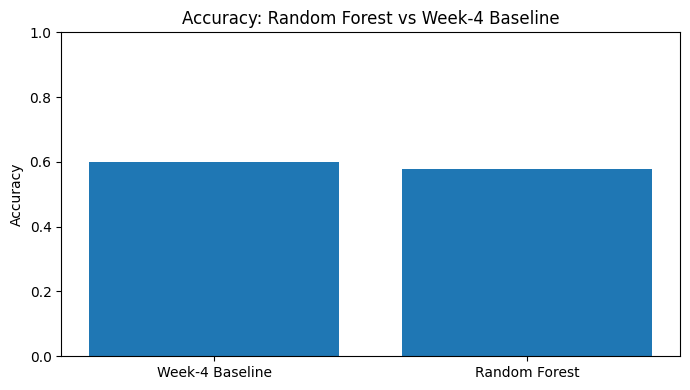

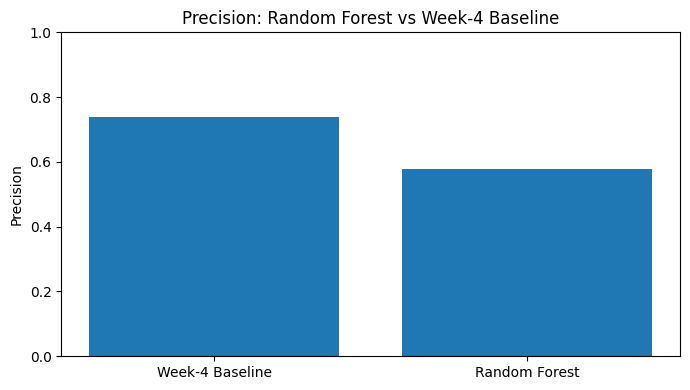

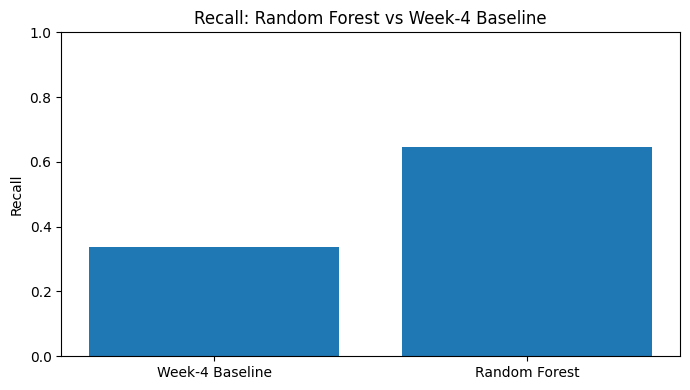

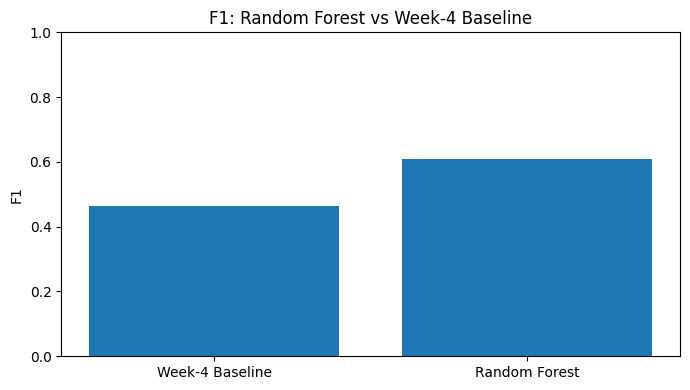

In [14]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1"]

for metric in metrics:
    plt.figure(figsize=(7, 4))

    plt.bar(
        results["Method"],
        results[metric]
    )

    plt.ylabel(metric)
    plt.title(f"{metric}: Random Forest vs Week-4 Baseline")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

## 5. Limitations

*What this work cannot claim.*

###Limitations & Honest Framing

This analysis has several important limitations.

First, the working analysis uses a 30,000-row anonymized starter sample rather than the complete FlyRank warehouse. The measured results should therefore be treated as directional evidence from this sample.

Second, the target is an observed impression-decline rule. It does not establish why impressions declined or whether a content refresh would reverse the decline.

Third, the grouped validation prevents client overlap between training and test data, but it does not guarantee that the model will generalize to future periods, new clients, or different search environments.

Fourth, the model features represent measurable signals available in the dataset but cannot capture every factor affecting search performance.

Finally, the model is decision-support. A prediction should not automatically trigger publication, deletion, redirection, rewriting, or other content changes.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked Recommendations
The action playbook converts observed decline signals into a review queue.

The highest-priority items are not automatically "pages to refresh." They are pages that warrant closer human investigation.

### Recommended action categories

**1. REVIEW_REFRESH — Declining impressions**

Content showing the observed decline condition should receive human review.

**2. REVIEW_REFRESH — Declining + low position**

Pages showing decline alongside weaker observed average position should receive additional search-performance review.

**3. REVIEW_REFRESH — Declining + older content**

Older content showing the decline signal should be checked for relevance, completeness, and freshness.

**4. REVIEW_REFRESH — Declining + stale**

Pages showing decline and long time since update should receive closer review of whether the content remains current.

**5. KEEP_MONITORING**

Pages without sufficient observed evidence for the review queue should remain under monitoring rather than being changed automatically.

These recommendations are prioritization rules. They do not establish that refreshing a page will improve its future performance.

In [15]:
# Build the action playbook

df["impression_change_pct"] = np.where(
    df["impressions_prev_30d"] > 0,
    (
        (df["impressions_last_30d"] -
         df["impressions_prev_30d"])
        / df["impressions_prev_30d"]
    ) * 100,
    np.nan
)

df["action_label"] = np.where(
    df["is_declining"] == 1,
    "REVIEW_REFRESH",
    "KEEP_MONITORING"
)

def get_reason_code(row):

    if row["is_declining"] == 1:

        if (
            pd.notna(row["days_since_last_update"])
            and row["days_since_last_update"] >= 180
        ):
            return "DECLINING_AND_STALE"

        if (
            pd.notna(row["content_age_days"])
            and row["content_age_days"] >= 365
        ):
            return "DECLINING_OLDER_CONTENT"

        if (
            pd.notna(row["avg_position"])
            and row["avg_position"] > 20
        ):
            return "DECLINING_LOW_POSITION"

        return "DECLINING_IMPRESSIONS"

    return "KEEP_MONITORING"


df["reason_code"] = df.apply(
    get_reason_code,
    axis=1
)

df["action_order"] = np.where(
    df["action_label"] == "REVIEW_REFRESH",
    0,
    1
)

df = df.sort_values(
    by=[
        "action_order",
        "impression_change_pct"
    ],
    ascending=[
        True,
        True
    ],
    na_position="last"
)

queue_columns = [
    "content_id",
    "action_label",
    "reason_code",
    "impression_change_pct",
    "impressions_last_30d",
    "impressions_prev_30d",
    "days_since_last_update",
    "content_age_days",
    "avg_position"
]

action_queue = df[queue_columns].copy()

print("Action counts:")
print(action_queue["action_label"].value_counts())

print("\nReason-code counts:")
print(action_queue["reason_code"].value_counts())

print("\nTop 10:")
display(action_queue.head(10))

Action counts:
action_label
REVIEW_REFRESH     16262
KEEP_MONITORING    13738
Name: count, dtype: int64

Reason-code counts:
reason_code
KEEP_MONITORING            13738
DECLINING_IMPRESSIONS       9727
DECLINING_LOW_POSITION      3745
DECLINING_OLDER_CONTENT     2708
DECLINING_AND_STALE           82
Name: count, dtype: int64

Top 10:


,content_id,action_label,reason_code,impression_change_pct,impressions_last_30d,impressions_prev_30d,days_since_last_update,content_age_days,avg_position
23,content_2da6ae9d0882,REVIEW_REFRESH,DECLINING_OLDER_CONTENT,-100.0,0,34,20,502,13.9
39,content_4595e8704e07,REVIEW_REFRESH,DECLINING_LOW_POSITION,-100.0,0,4,104,348,36.3
48,content_326fa2fa449f,REVIEW_REFRESH,DECLINING_IMPRESSIONS,-100.0,0,3,1,91,8.3
49,content_f0717373e86e,REVIEW_REFRESH,DECLINING_IMPRESSIONS,-100.0,0,1,8,174,10.1
51,content_d8a23b5e10c5,REVIEW_REFRESH,DECLINING_IMPRESSIONS,-100.0,0,1,8,126,7.5
67,content_9042a5355ff7,REVIEW_REFRESH,DECLINING_IMPRESSIONS,-100.0,0,10,8,91,5.0
68,content_6bc2ec5f6061,REVIEW_REFRESH,DECLINING_LOW_POSITION,-100.0,0,124,8,125,23.0
111,content_46eaff5b4ae8,REVIEW_REFRESH,DECLINING_OLDER_CONTENT,-100.0,0,3,22,441,16.3
130,content_27682a7cd588,REVIEW_REFRESH,DECLINING_IMPRESSIONS,-100.0,0,11,8,90,9.4
141,content_0af426466565,REVIEW_REFRESH,DECLINING_IMPRESSIONS,-100.0,0,8,8,91,3.6


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Artifacts the Paper Embeds

The capstone produces a model comparison table, performance charts, and a ranked action queue.

These artifacts are intended to make the analysis inspectable and reproducible. The queue contains observed signals and reason codes for human review rather than automatic instructions.

In [16]:
import os

output_dir = "/content/capstone_outputs"
os.makedirs(output_dir, exist_ok=True)

# Results table
results.to_csv(
    f"{output_dir}/model_results.csv",
    index=False
)

# Action queue
action_queue.to_csv(
    f"{output_dir}/content_action_queue.csv",
    index=False
)

# Action summary
action_summary = (
    action_queue["action_label"]
    .value_counts()
    .rename_axis("action_label")
    .reset_index(name="count")
)

action_summary.to_csv(
    f"{output_dir}/action_summary.csv",
    index=False
)

# Reason summary
reason_summary = (
    action_queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="count")
)

reason_summary.to_csv(
    f"{output_dir}/reason_summary.csv",
    index=False
)

print("Artifacts created:")

for filename in os.listdir(output_dir):
    print("-", filename)

Artifacts created:
- action_summary.csv
- model_results.csv
- reason_summary.csv
- content_action_queue.csv


# ML-12 — Demo & Employer-Facing Summary

## 5-Minute Demo Outline

**1. Problem — 45 seconds**

Explain that the project asks whether observable search and content signals can help prioritize potentially declining content.

**2. Data and target — 45 seconds**

Explain the 30,000-row anonymized dataset and the observed decline definition.

**3. Method — 60 seconds**

Explain the Random Forest, the transparent baseline, client-grouped validation, and leakage checks.

**4. Results — 60 seconds**

Show that the Random Forest achieved F1 = 0.6096 compared with 0.4629 for the baseline, while explaining the precision-recall trade-off.

**5. Action playbook — 45 seconds**

Show how the model findings become a human-review queue rather than automatic content changes.

**6. Honest conclusion — 25 seconds**

Explain that the results are directional evidence from the sample and do not prove causation or guaranteed improvement after refreshing content.

---

## Social-post cut

I built a search-intelligence analysis to investigate whether observable content and performance signals can help prioritize potentially declining content.

Using a 30,000-row anonymized dataset, I compared a Random Forest with a transparent baseline using client-grouped validation. The Random Forest achieved an F1 score of 0.6096 versus 0.4629 for the baseline, with higher recall but lower precision.

The main lesson was not simply that the model "won," but that model performance needs to be interpreted alongside validation design, leakage checks, and the real decision the model supports.

---

## Employer-facing summary

I built an end-to-end search-intelligence workflow that moved from research question and data validation to baseline modeling, Random Forest classification, leakage auditing, validation, and an action playbook. The model achieved a measured F1 score of 0.6096 on a client-grouped holdout compared with 0.4629 for the baseline, while exposing a clear precision-recall trade-off. I designed the final output as decision-support rather than an automated content-changing system, with explicit validation, leakage, and monitoring controls.

## Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

Data source: [FlyRank](https://flyrank.ai)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
